In [ ]:
# Retail Demand Forecasting using Machine Learning

## Notebook 4

# Decision Tree Regression

---

### Objectives

- Load Dataset
- Data Preparation
- Decision Tree Training
- Model Evaluation
- Feature Importance
- Save Model

In [ ]:
# ==============================================================================
# INSTALL REQUIRED LIBRARIES
# ==============================================================================

# Uncomment if required

# %pip install scikit-learn
# %pip install joblib
# %pip install matplotlib
# %pip install seaborn

In [1]:
# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

import warnings
warnings.filterwarnings("ignore")

import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==============================================================================
# DISPLAY SETTINGS
# ==============================================================================

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns",None)

In [4]:
# ==============================================================================
# LOAD DATASET
# ==============================================================================

df = pd.read_csv(r"C:\Users\asus\Desktop\RETAIL\dataset\retail_cleaned.csv")

print(df.shape)

(8601, 33)


In [5]:
# ==============================================================================
# DATA PREVIEW
# ==============================================================================

df.head()

,Date,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Sales,Year,Month,Day,Week,Quarter,Day_Name,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
0,2023-01-01,41,1029,2,0,0,0,2,32.1,107.07,287.06,3.78,452,111.98,102.88,14,278,27,2023,1,1,52,1,3,4,1,3,1.620072,9.10,15.6772,96.3028,0.096774,0
1,2023-01-02,46,1167,5,3,0,1,0,18.3,114.77,271.06,4.44,452,713.49,664.33,48,192,54,2023,1,2,1,1,1,4,0,3,2.341969,49.16,342.4752,371.0148,0.279793,48
2,2023-01-03,7,1024,3,1,1,1,0,17.9,81.74,235.13,4.12,964,788.14,796.34,40,336,146,2023,1,3,1,1,5,4,0,3,2.860534,-8.20,315.2560,472.8840,0.433234,40
3,2023-01-04,13,1181,2,1,0,1,2,35.7,114.66,225.62,7.08,874,761.42,741.65,13,363,135,2023,1,4,1,1,6,4,0,3,2.401099,19.77,98.9846,662.4354,0.370879,13
4,2023-01-05,18,1180,5,1,0,0,2,23.9,90.80,291.05,9.19,244,1385.00,1479.97,49,48,0,2023,1,5,1,1,4,4,0,3,4.979592,-94.97,678.6500,706.3500,0.000000,0


In [6]:
# ==============================================================================
# CHECK MISSING VALUES
# ==============================================================================

df.isnull().sum()

Date                      0
Store_ID                  0
Product_ID                0
Category                  0
Region                    0
Holiday                   0
Promotion                 0
Weather                   0
Temperature               0
Fuel_Price                0
CPI                       0
Unemployment              0
Inventory                 0
Price                     0
Competitor_Price          0
Discount                  0
Customers                 0
Sales                     0
Year                      0
Month                     0
Day                       0
Week                      0
Quarter                   0
Day_Name                  0
Month_Name                0
Weekend                   0
Season                    0
Inventory_Per_Customer    0
Price_Difference          0
Discount_Amount           0
Final_Price               0
Sales_Per_Customer        0
Promotion_Impact          0
dtype: int64

In [7]:
# ==============================================================================
# DEFINE TARGET
# ==============================================================================

TARGET = "Sales"

In [8]:
# ==============================================================================
# INPUT AND OUTPUT
# ==============================================================================

X = df.drop(columns=[TARGET])

y = df[TARGET]

In [9]:
# ==============================================================================
# REMOVE DATE COLUMN IF PRESENT
# ==============================================================================

if "Date" in X.columns:
    X = X.drop(columns=["Date"])

In [10]:
# ==============================================================================
# LABEL ENCODING
# ==============================================================================

encoder = LabelEncoder()

for col in X.select_dtypes(include="object").columns:

    X[col] = encoder.fit_transform(X[col])

In [11]:
# ==============================================================================
# TRAIN TEST SPLIT
# ==============================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(6880, 31)
(1721, 31)


In [12]:
# ==============================================================================
# CREATE MODEL
# ==============================================================================

dt_model = DecisionTreeRegressor(

    random_state=42,

    max_depth=10,

    min_samples_split=5,

    min_samples_leaf=2
)

In [13]:
# ==============================================================================
# TRAIN MODEL
# ==============================================================================

dt_model.fit(

    X_train,

    y_train
)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [14]:
# ==============================================================================
# TRAIN PREDICTIONS
# ==============================================================================

y_train_pred = dt_model.predict(X_train)

In [15]:
# ==============================================================================
# TEST PREDICTIONS
# ==============================================================================

y_test_pred = dt_model.predict(X_test)

In [16]:
# ==============================================================================
# MODEL METRICS
# ==============================================================================

mae = mean_absolute_error(y_test, y_test_pred)

mse = mean_squared_error(y_test, y_test_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_test_pred)

print("MAE :",mae)

print("MSE :",mse)

print("RMSE :",rmse)

print("R2 :",r2)

MAE : 1.689338940910022
MSE : 5.797634573720753
RMSE : 2.407827770776131
R2 : 0.9979630103848741


In [17]:
# ==============================================================================
# PERFORMANCE TABLE
# ==============================================================================

performance = pd.DataFrame({

"Metric":["MAE","MSE","RMSE","R2"],

"Value":[mae,mse,rmse,r2]

})

performance

,Metric,Value
0,MAE,1.689339
1,MSE,5.797635
2,RMSE,2.407828
3,R2,0.997963


In [18]:
# ==============================================================================
# ACTUAL VS PREDICTED
# ==============================================================================

prediction_df = pd.DataFrame({

"Actual":y_test,

"Predicted":y_test_pred

})

prediction_df.head(20)

,Actual,Predicted
5839,6,4.882353
4275,91,90.888889
6086,49,51.125000
8265,90,88.250000
5493,15,17.615385
1688,127,125.500000
5241,59,59.352941
221,53,48.875000
239,63,64.000000
2208,53,56.000000


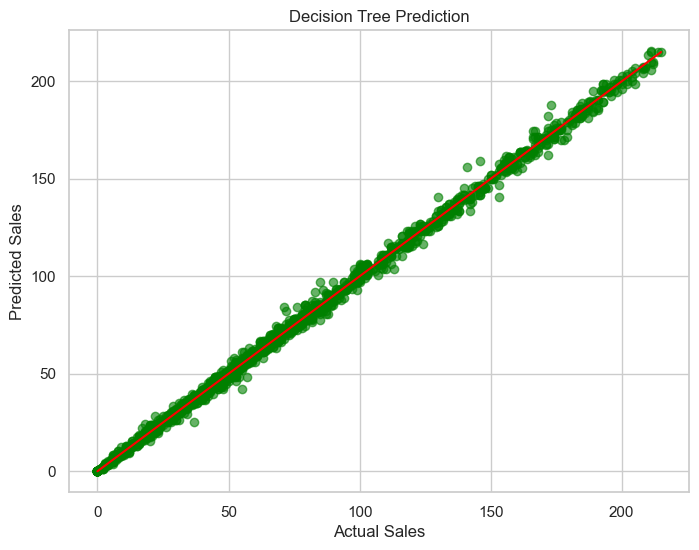

In [19]:
# ==============================================================================
# ACTUAL VS PREDICTED SCATTER
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    y_test_pred,

    alpha=0.6,

    color="green"

)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red"

)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Decision Tree Prediction")

plt.show()

In [21]:
# ==============================================================================
# TRAINING R² SCORE
# ==============================================================================

train_r2 = r2_score(y_train, y_train_pred)

print("Training R² Score :", train_r2)

Training R² Score : 0.9994793104751476


In [22]:
# ==============================================================================
# TESTING R² SCORE
# ==============================================================================

test_r2 = r2_score(y_test, y_test_pred)

print("Testing R² Score :", test_r2)

Testing R² Score : 0.9979630103848741


In [23]:

# ==============================================================================
# ADJUSTED R² SCORE
# ==============================================================================

n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - test_r2) * (n - 1) / (n - p - 1))

print("Adjusted R² :", adjusted_r2)

Adjusted R² : 0.997925623364111


In [24]:
# ==============================================================================
# MEAN ABSOLUTE PERCENTAGE ERROR (MAPE)
# ==============================================================================

mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print("MAPE :", round(mape,2), "%")

MAPE : 3.51 %


In [25]:
# ==============================================================================
# RESIDUALS
# ==============================================================================

residuals = y_test - y_test_pred

residuals.head()

5839    1.117647
4275    0.111111
6086   -2.125000
8265    1.750000
5493   -2.615385
Name: Sales, dtype: float64

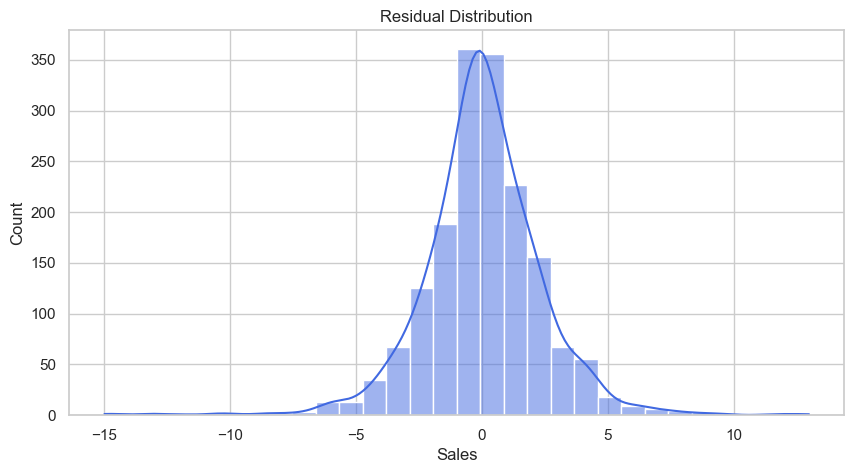

In [26]:
# ==============================================================================
# RESIDUAL DISTRIBUTION
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Residual Distribution")

plt.show()

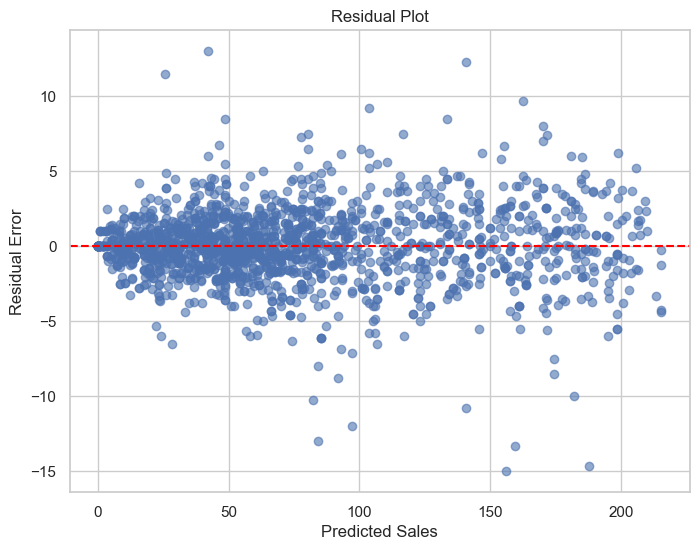

In [27]:
# ==============================================================================
# RESIDUAL SCATTER PLOT
# ==============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual Error")

plt.title("Residual Plot")

plt.show()

In [28]:
# ==============================================================================
# FEATURE IMPORTANCE
# ==============================================================================

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": dt_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
29,Sales_Per_Customer,0.592451
15,Customers,0.407339
1,Product_ID,0.000029
26,Price_Difference,0.000023
10,Unemployment,0.000022
9,CPI,0.000020
8,Fuel_Price,0.000014
19,Week,0.000011
25,Inventory_Per_Customer,0.000011
27,Discount_Amount,0.000010


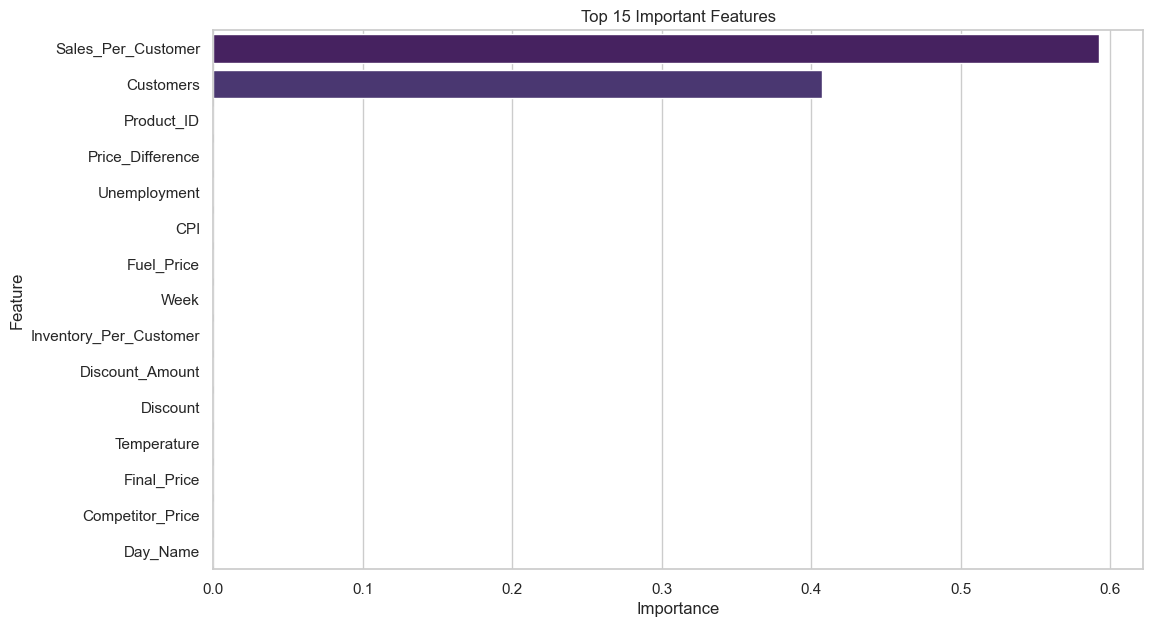

In [29]:
# ==============================================================================
# TOP 15 IMPORTANT FEATURES
# ==============================================================================

plt.figure(figsize=(12,7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Important Features")

plt.show()

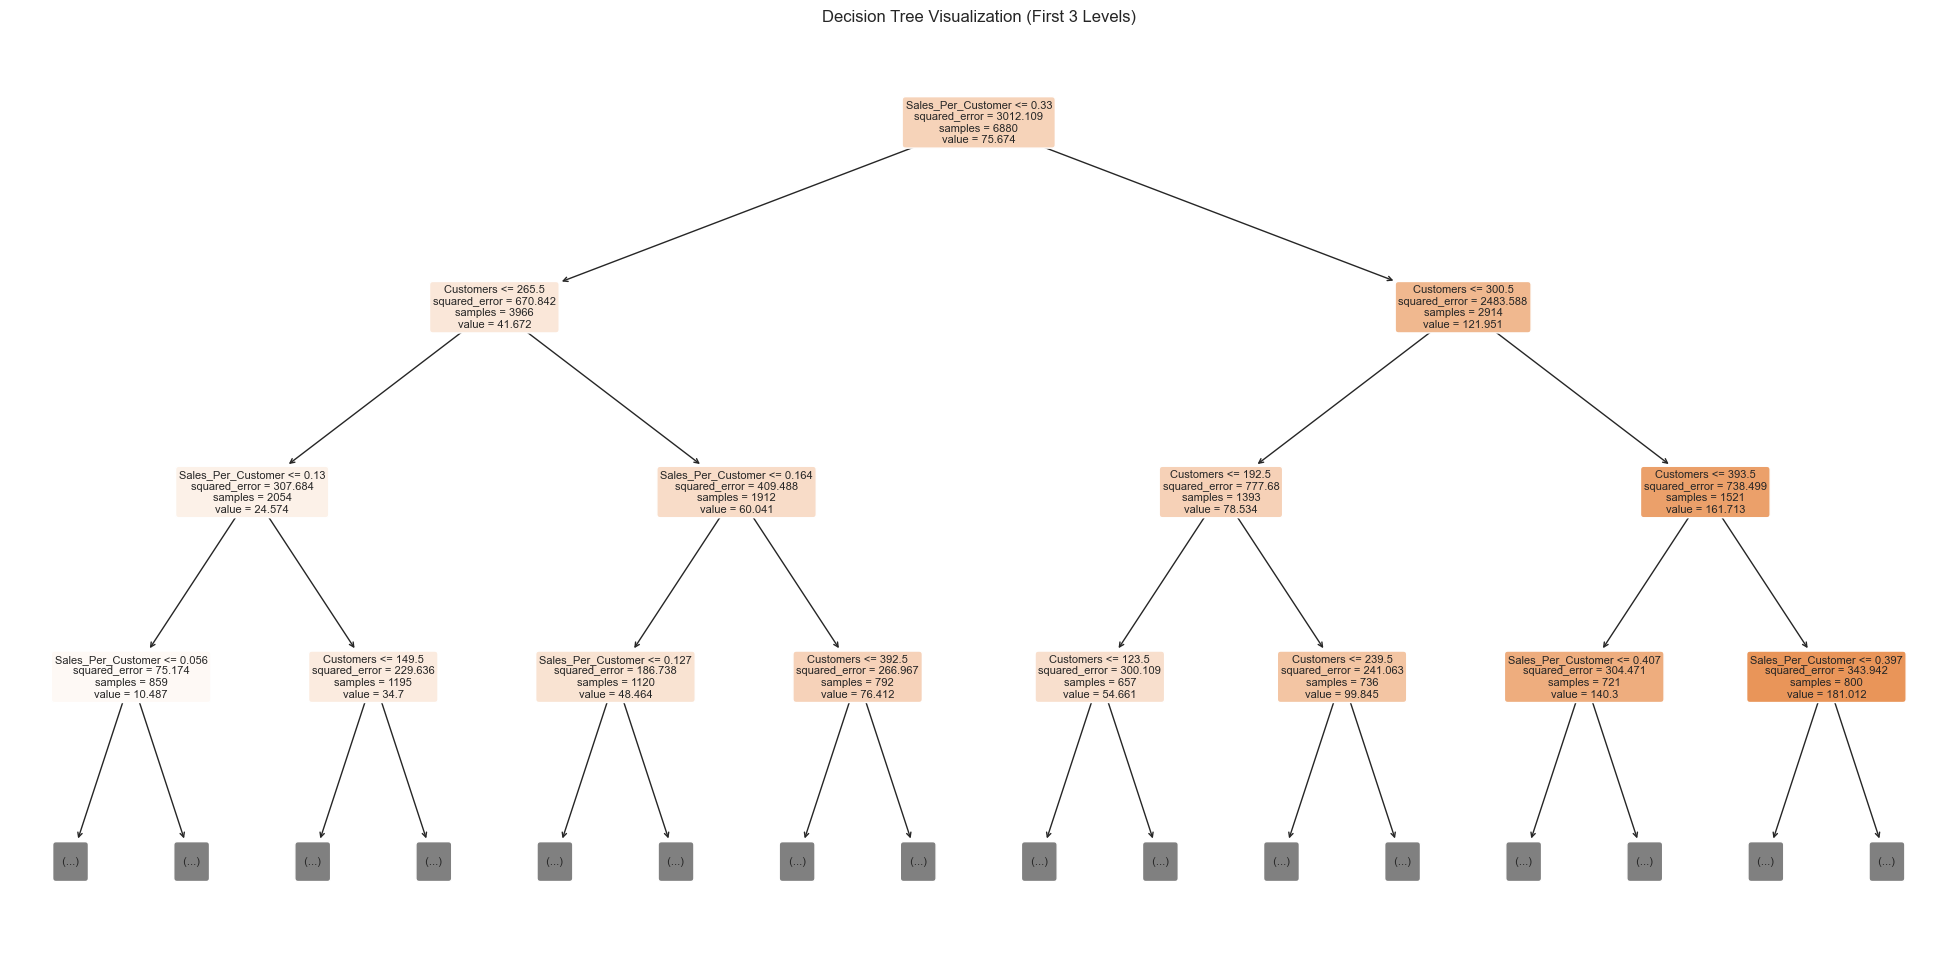

In [32]:
# ==============================================================================
# VISUALIZE DECISION TREE (FIRST 3 LEVELS)
# ==============================================================================

from sklearn.tree import plot_tree

plt.figure(figsize=(25,12))

plot_tree(
    decision_tree=dt_model,
    feature_names=X.columns.tolist(),   # Convert Index to list
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization (First 3 Levels)")

plt.show()

In [33]:
# ==============================================================================
# CROSS VALIDATION
# ==============================================================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(cv_scores)

[0.99801118 0.99711511 0.99812592 0.99793391 0.99748936]


In [34]:
# ==============================================================================
# AVERAGE CROSS VALIDATION SCORE
# ==============================================================================

print("Average CV Score :", cv_scores.mean())

Average CV Score : 0.9977350943200547


In [35]:
# ==============================================================================
# PERFORMANCE SUMMARY
# ==============================================================================

summary = pd.DataFrame({

    "Metric":[
        "MAE",
        "MSE",
        "RMSE",
        "R²",
        "Adjusted R²",
        "MAPE"
    ],

    "Value":[
        mae,
        mse,
        rmse,
        test_r2,
        adjusted_r2,
        mape
    ]

})

summary

,Metric,Value
0,MAE,1.689339
1,MSE,5.797635
2,RMSE,2.407828
3,R²,0.997963
4,Adjusted R²,0.997926
5,MAPE,3.510447


In [36]:
# ==============================================================================
# SAVE MODEL
# ==============================================================================

import os

os.makedirs("model", exist_ok=True)

joblib.dump(
    dt_model,
    "model/decision_tree.pkl"
)

print("Decision Tree Model Saved Successfully")

Decision Tree Model Saved Successfully


In [37]:
# ==============================================================================
# SAVE PREDICTIONS
# ==============================================================================

os.makedirs("dataset", exist_ok=True)

prediction_df.to_csv(
    "dataset/decision_tree_predictions.csv",
    index=False
)

print("Predictions Saved Successfully")

Predictions Saved Successfully


In [38]:
# ==============================================================================
# SAVE PERFORMANCE REPORT
# ==============================================================================

summary.to_csv(
    "dataset/DecisionTree_Performance.csv",
    index=False
)

print("Performance Report Saved")

Performance Report Saved


In [39]:
# ==============================================================================
# VERIFY MODEL FILES
# ==============================================================================

print(os.listdir("model"))

['decision_tree.pkl', 'label_encoder.pkl', 'linear_regression.pkl', 'linear_scaler.pkl', 'scaler.pkl']


In [40]:
# ==============================================================================
# VERIFY DATASET FILES
# ==============================================================================

print(os.listdir("dataset"))

['DecisionTree_Performance.csv', 'decision_tree_predictions.csv', 'Linear_Regression_Performance.csv', 'linear_regression_predictions.csv']


In [41]:
# ==============================================================================
# BUSINESS INTERPRETATION
# ==============================================================================

print("Business Interpretation")

print("- Decision Tree captures non-linear relationships.")
print("- It can identify complex sales patterns.")
print("- Feature importance helps identify key demand drivers.")
print("- Compare this model with Linear Regression in Notebook 11.")

Business Interpretation
- Decision Tree captures non-linear relationships.
- It can identify complex sales patterns.
- Feature importance helps identify key demand drivers.
- Compare this model with Linear Regression in Notebook 11.
